<a href="https://colab.research.google.com/github/jonay-lab/Assignment_Practice/blob/main/Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment_6:Housing Price Prediction using California Housing Data**

**Problem Statement**

The goal of this project is to build a machine learning regression model to predict house prices using housing features. The project also aims to identify the most important features that influence house prices and evaluate their impact on prediction accuracy.


data source: Kaggle

the content of data:
1. longitude: A measure of how far west a house is; a higher value is farther west
2. latitude: A measure of how far north a house is; a higher value is farther north
3. housingMedianAge: Median age of a house within a block; a lower number is a newer building
4. totalRooms: Total number of rooms within a block
5. totalBedrooms: Total number of bedrooms within a block
6. population: Total number of people residing within a block
7. households: Total number of households, a group of people residing within a home unit, for a block
8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)
9. medianHouseValue: Median house value for households within a block (measured in US Dollars)
10. oceanProximity: Location of the house w.r.t ocean/sea.

Import all the necessary libraries for data handling, visualization, and model building

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

loading the data set and discovering

In [23]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Data_set/housing.csv')
df.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY


Check the features and target variable. Identify which is continuous and categorical if applicable.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


 **EDA and Data Preprocessing**

Check for missing/null values.

In [26]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


**Handling missing values**

Missing values can be handled using different methods based on the features distribution or its correlation with other features . since total_bedrooms is highly correlated with total_rooms. i used  a linear equation to fill the missing values.(i would use some error value but for simplicity i did it this way)

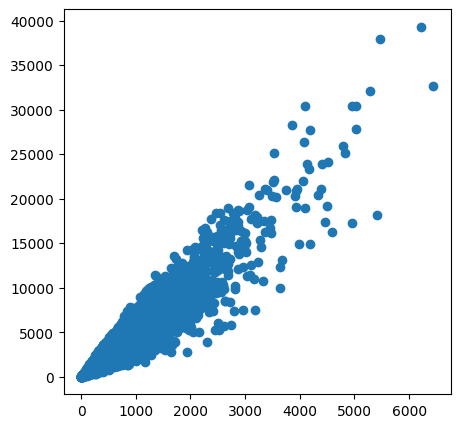

In [27]:

plt.figure(figsize=(5,5))
plt.scatter(x = df['total_bedrooms'],y=df['total_rooms'])
plt.show()

In [29]:
# simple lineare equation i solve fill the null values.
df_m = df[df['total_bedrooms'].isnull()]
df_n = df[df['total_bedrooms'].notnull()]
a1= df_m['total_bedrooms']
b1 = df_m['total_rooms']

a2= df_n['total_bedrooms']
b2 = df_n['total_rooms']
a2 = df_n['total_bedrooms']
b2 = df_n['total_rooms']
m = ((b2 - b2.mean()) * (a2 - a2.mean())).sum() / ((b2 - b2.mean())**2).sum()
b = a2.mean() - m * b2.mean()
a1 = m * b1 + b
df['total_bedrooms'] = df['total_bedrooms'].fillna(a1)

In [30]:
df.isnull().sum()


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


**Checking outliners:**

in outliners we always consider two points:

1: the value of row compared with other rows.
2: knowing the meaning or the context of the value.

here there are outliners but it is reasonable


<function matplotlib.pyplot.show(close=None, block=None)>

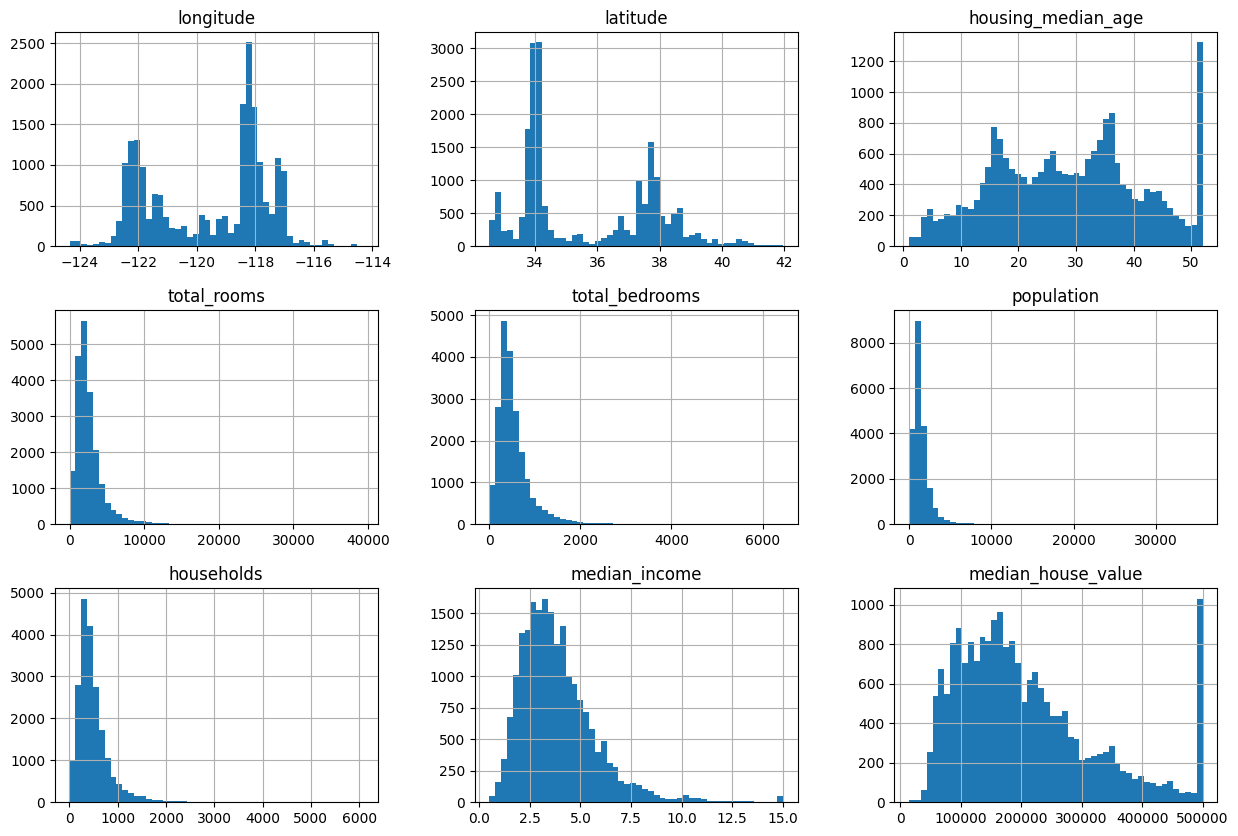

In [31]:
df.hist(bins= 50,figsize=(15,10))
plt.show

**Relationship with Multiple features and the target variable**


There are two approaches. one compare median_house_value with longitude, latitude, and population to show how prices vary by location(idea taken from a GitHub project). the other method simply compares all features with the target variables.

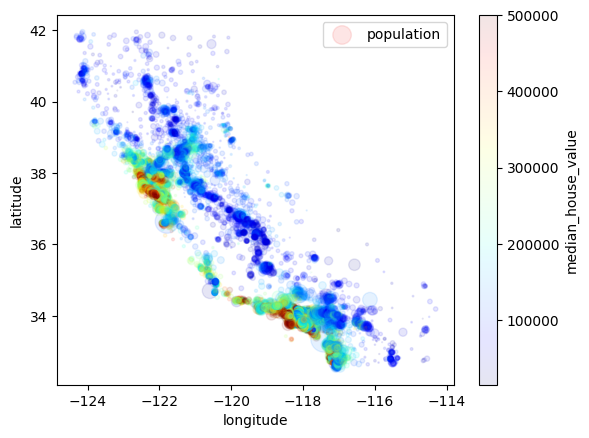

In [33]:
def plot_geo_scatter(df, x, y, size_col, color_col):
    df.plot(kind="scatter", x=x, y=y,
            alpha=0.1, s=df[size_col]/100, label=size_col,
            c=color_col, cmap=plt.get_cmap("jet"))
    plt.legend()
    plt.show()
plot_geo_scatter(df, "longitude", "latitude", "population", "median_house_value")



Red indicates high prices, while blue represents the cheapest prices. from the visualization, we can see that high-priced houses are often located in the same areas, and the cheaper houses are also clustered in specific locations.

<Figure size 640x480 with 0 Axes>

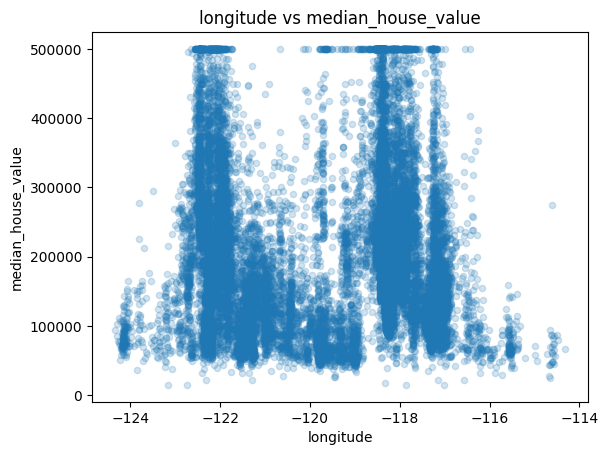

<Figure size 640x480 with 0 Axes>

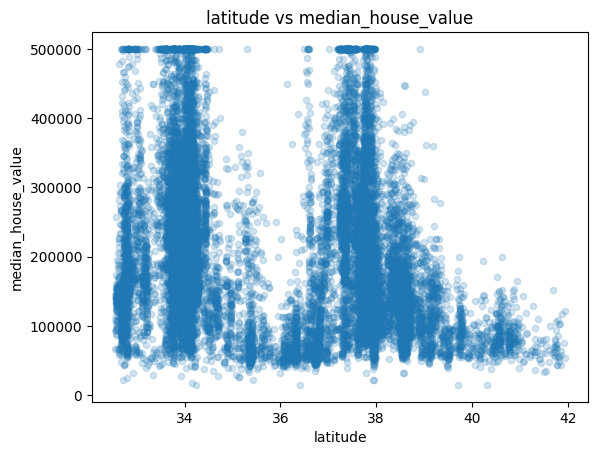

<Figure size 640x480 with 0 Axes>

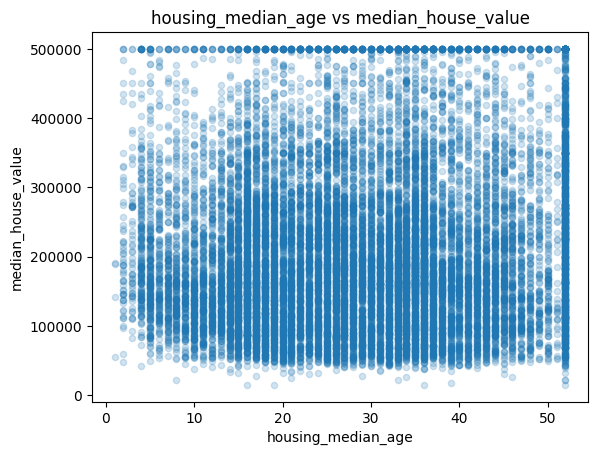

<Figure size 640x480 with 0 Axes>

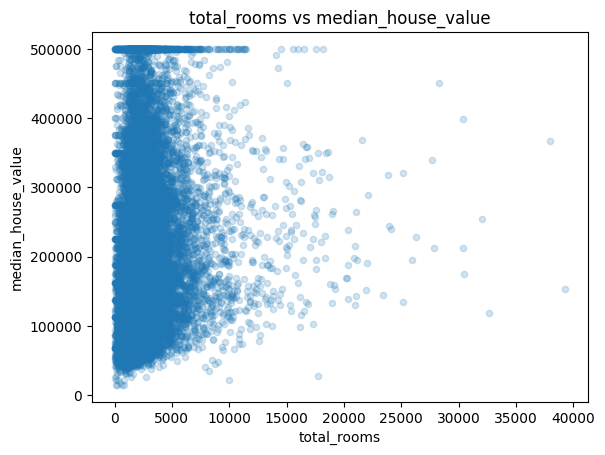

<Figure size 640x480 with 0 Axes>

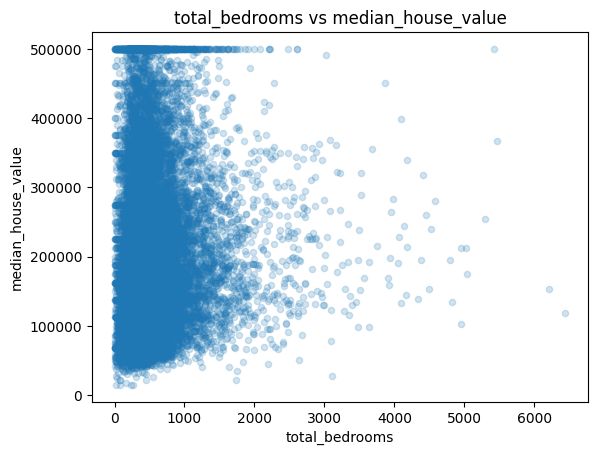

<Figure size 640x480 with 0 Axes>

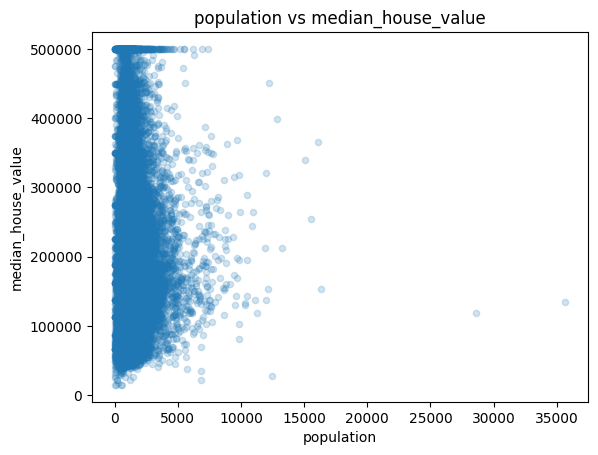

<Figure size 640x480 with 0 Axes>

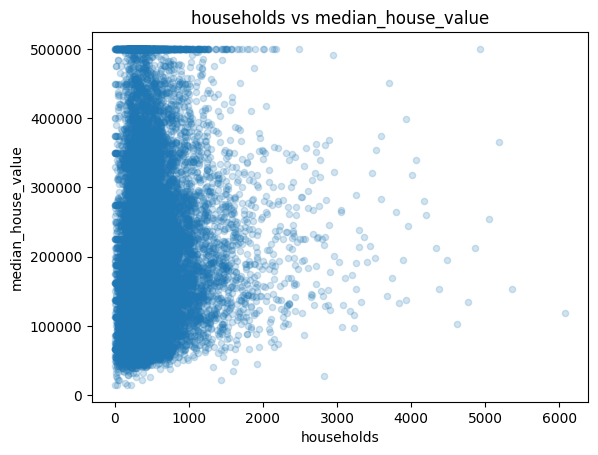

<Figure size 640x480 with 0 Axes>

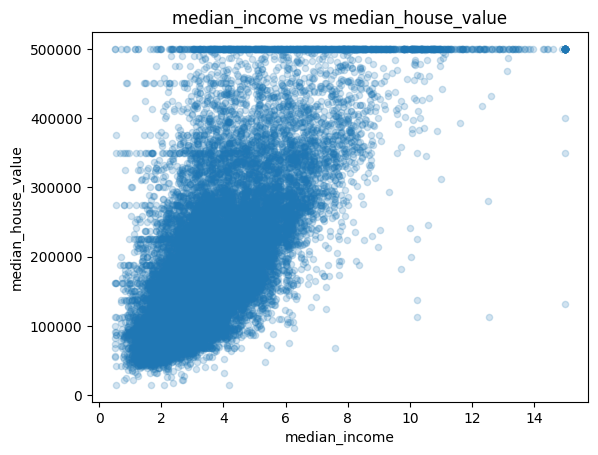

In [38]:

def plot_feature_scatter(df, target="median_house_value"):
    numerical_cols = df.select_dtypes(include="number").columns
    features = numerical_cols.drop(target, errors='ignore')
    for feature in features:
        plt.figure()
        df.plot(kind="scatter",
                x=feature,
                y=target,
                alpha=0.2)
        plt.title(f"{feature} vs {target}")
        plt.show()
plot_feature_scatter(df)

**building correlation is best option for knowing the relation between features target values.**

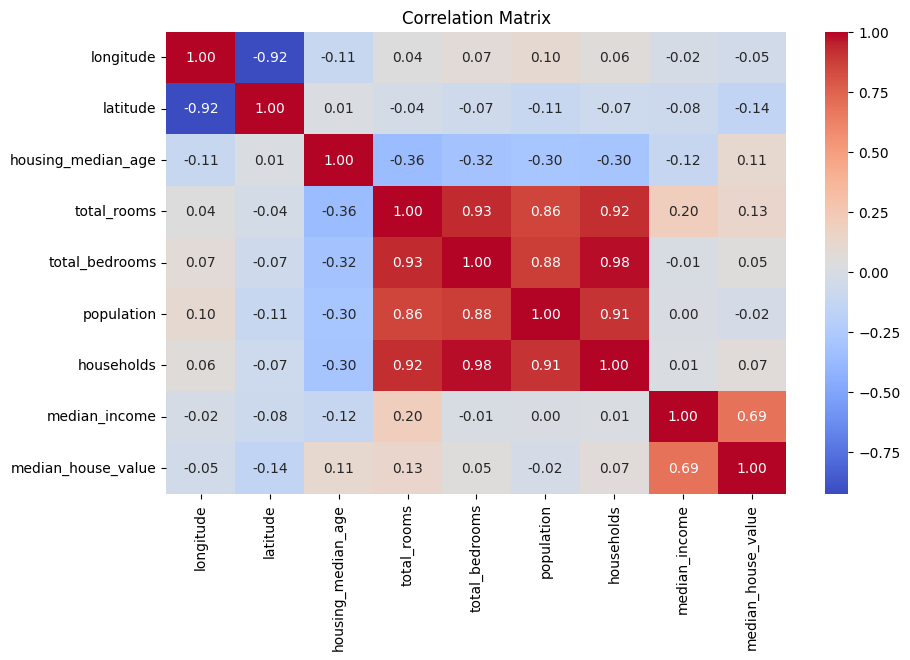

In [39]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

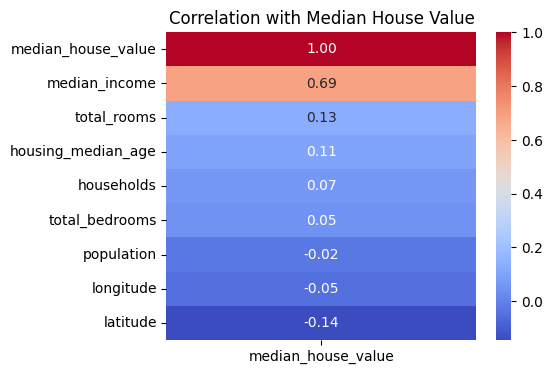

In [44]:
corr_matrix = df.corr(numeric_only=True)
target_corr = corr_matrix[["median_house_value"]].sort_values(
    by="median_house_value",
    ascending=False)
plt.figure(figsize=(5, 4))
sns.heatmap(target_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation with Median House Value")
plt.show()

Median income is the most important feature for predicting house prices, while most other features have weak or nearly no linear relation with the target.

**Changing Categorical data**

In [46]:
dummies = pd.get_dummies(df['ocean_proximity'],drop_first=True)

**ML Model Training**

In [49]:

feature_cols = ["median_income", "housing_median_age", "total_rooms", "total_bedrooms",
                 "population", "households", "latitude", "longitude"]
X = df[feature_cols]
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

Model_Evaluation

In [51]:
Y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, Y_pred)
print(f"Mean Squared Error: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

Mean Squared Error: 70349.0345
R-squared: 0.6223



The model achieved an rsquared score of 0.62 ,meaning it explains about 62% of the variation in house prices using the available features . this shows that the model captures many important patterns in the data. however, around 38% of the variation is still not explained , which may be due to missing features or complex relationships.

mean squared error of 70349 indicates average squared difference actual value and predict value.this indicates the model has still noticable error.
overall , the model performs reasonably well but still has room for improvement.

 **Model Prediction**

 Predict Median House Value from a new set of feature inputs

In [53]:
new_data = pd.DataFrame([{
    "median_income": 3.0,
    "housing_median_age": 30.0,
    "total_rooms": 2000.0,
    "total_bedrooms": 400.0,
    "population": 1500.0,
    "households": 400.0,
    "latitude": 34.0,
    "longitude": -118.0
}])
predicted_value = model.predict(new_data)
print(f"Predicted Median House Value: {predicted_value[0]:.4f}")

Predicted Median House Value: 157121.8530


the link